# IEEE-CIS Fraud Detection: Exploratory Data Analysis (EDA)

## 1. Environment Setup and Imports

Initialize required core scientific libraries, configure visualization themes, and dynamically import project utility modules from the `src` directory.

In [5]:
import sys
import importlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Add project root path
sys.path.append("..")

import src.data.loader
importlib.reload(src.data.loader)

from src.data.loader import load_data

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

print("Libraries imported and module reloaded successfully!")

Libraries imported and module reloaded successfully!


## 2. Data Loading & Sampling Strategy

To optimize memory consumption while maintaining temporal representation across the entire dataset timeline, we sample every 12th record (~50,000 rows) from `train_transaction.csv` and perform a left merge with `train_identity.csv` on `TransactionID`.

In [6]:
import os
import pandas as pd

# Load ~50,000 rows evenly sampled across the entire timeline to avoid memory issues and temporal bias
data_dir = "../data/raw"
sample_step = 12

train_trans = pd.read_csv(
    os.path.join(data_dir, "train_transaction.csv"),
    skiprows=lambda idx: idx > 0 and idx % sample_step != 0
)

train_id = pd.read_csv(os.path.join(data_dir, "train_identity.csv"))

# Merge transaction and identity data on TransactionID
train_df = pd.merge(train_trans, train_id, on="TransactionID", how="left")

print(f"Dataset Shape for EDA: {train_df.shape}")

Dataset Shape for EDA: (49211, 434)


## 3. Target Variable Class Imbalance

Examine the distribution of the target feature `isFraud` to quantify class imbalance in the training data.

Legitimate Transactions (0): 96.56%
Fraudulent Transactions (1): 3.44%


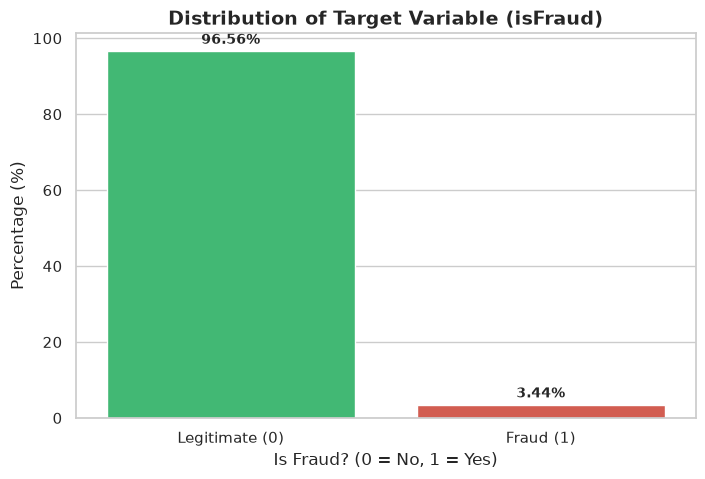

In [7]:
target_counts = train_df["isFraud"].value_counts(normalize=True) * 100

print(f"Legitimate Transactions (0): {target_counts[0]:.2f}%")
print(f"Fraudulent Transactions (1): {target_counts[1]:.2f}%")

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=target_counts.index,
    y=target_counts.values,
    hue=target_counts.index,
    palette=["#2ecc71", "#e74c3c"],
    legend=False
)
plt.title("Distribution of Target Variable (isFraud)", fontsize=14, fontweight="bold")
plt.xlabel("Is Fraud? (0 = No, 1 = Yes)")
plt.ylabel("Percentage (%)")
plt.xticks([0, 1], ["Legitimate (0)", "Fraud (1)"])

# Add exact percentage labels on top of bars
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}%",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 8),
        textcoords="offset points",
        fontweight="bold",
    )

plt.show()

> **Key Insight:**
> The dataset exhibits extreme class imbalance. Fraudulent transactions account for only **~3.44%** of total observations, whereas legitimate transactions constitute **~96.56%**. Standard evaluation metrics like Accuracy will be misleading; metrics such as ROC-AUC, PR-AUC, and F1-Score should be prioritized during model evaluation.

## 4. Transaction Amount Analysis

Analyze the distribution of transaction values (`TransactionAmt`) and apply log transformation (`log1p`) to mitigate extreme right-skewness and observe density differences between legitimate and fraudulent transactions.

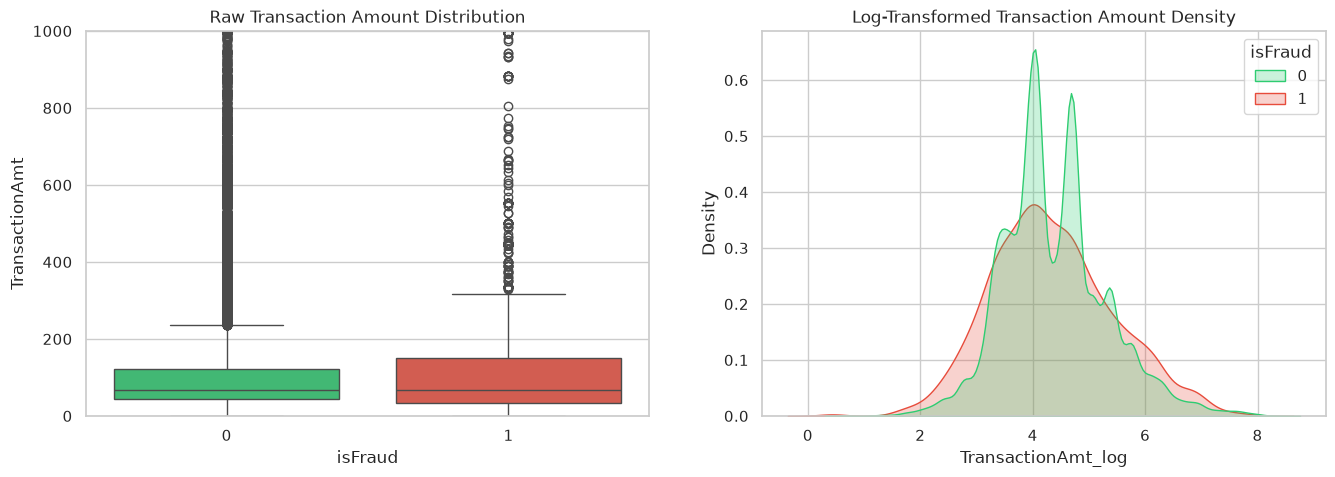

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Raw Transaction Amounts (Skewed)
sns.boxplot(
    x="isFraud",
    y="TransactionAmt",
    hue="isFraud",
    data=train_df,
    ax=axes[0],
    palette=["#2ecc71", "#e74c3c"],
    legend=False,
)
axes[0].set_title("Raw Transaction Amount Distribution")
axes[0].set_ylim(0, 1000)  # Zoom in to remove extreme outliers for visibility

# Log-transformed Transaction Amounts
train_df["TransactionAmt_log"] = np.log1p(train_df["TransactionAmt"])
sns.kdeplot(
    data=train_df,
    x="TransactionAmt_log",
    hue="isFraud",
    common_norm=False,
    ax=axes[1],
    palette=["#2ecc71", "#e74c3c"],
    fill=True,
)
axes[1].set_title("Log-Transformed Transaction Amount Density")

plt.show()

> **Key Insight:**
> - Raw transaction amounts are heavily right-skewed with significant high-value outliers.
> - The log-transformed density plot reveals subtle shifts: fraudulent transactions show a slightly higher proportion in specific price bands compared to legitimate ones, making log transformation (`np.log1p`) a useful feature for model training.

## 5. Missing Value Analysis

Quantify data completeness by identifying columns containing null values and evaluating the percentage of missing data across the features.

Total columns with missing values: 414


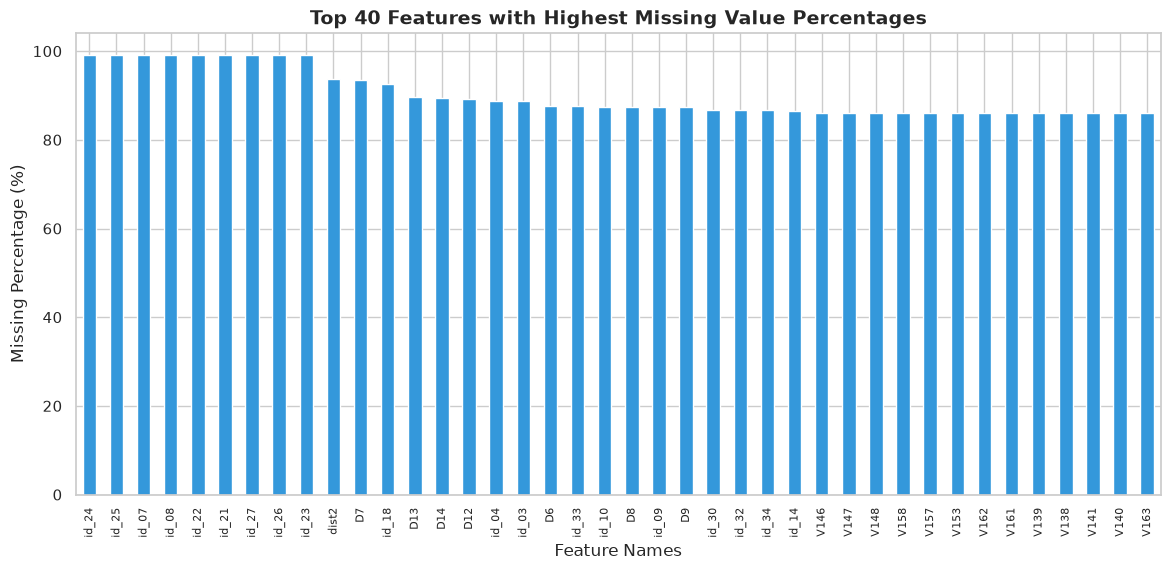

In [ ]:
null_percentages = (train_df.isnull().sum() / len(train_df)) * 100
null_percentages = null_percentages[null_percentages > 0].sort_values(
    ascending=False
)

print(f"Total columns with missing values: {len(null_percentages)}")

plt.figure(figsize=(14, 6))
null_percentages.head(40).plot(kind="bar", color="#3498db")
plt.title(
    "Top 40 Features with Highest Missing Value Percentages",
    fontsize=14,
    fontweight="bold",
)
plt.ylabel("Missing Percentage (%)")
plt.xlabel("Feature Names")
plt.xticks(rotation=90, fontsize=8)
plt.show()

> **Key Insight:**
> - The top 40 features exhibit extreme sparsity, with missing value proportions exceeding **85%** to nearly **100%** (especially among identity attributes like `id_24` to `id_23`).
> - Tree-based algorithms like LightGBM natively handle missing values; however, features with near-complete missingness require careful evaluation during feature selection or specialized missing-value indicator flags.

## 6. Temporal Feature Analysis (Hour of Day)

Extract the hourly temporal cycle from `TransactionDT` (measured in seconds) to analyze transaction volumes and evaluate how fraud probabilities fluctuate throughout a 24-hour cycle.

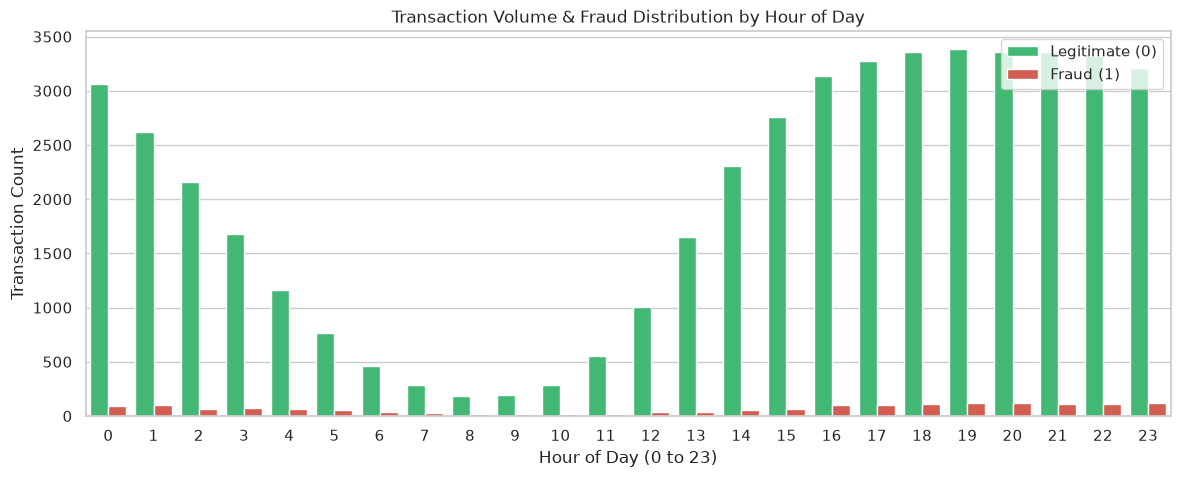

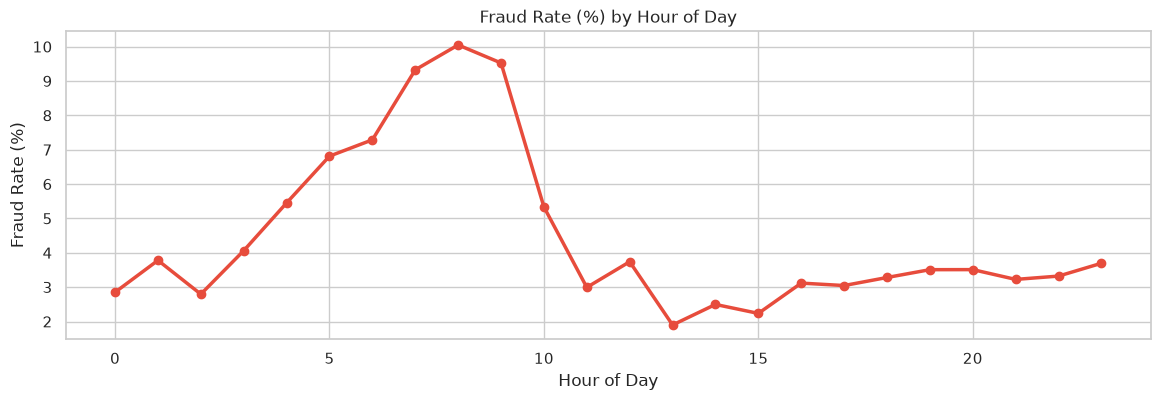

In [18]:
# Extract hour of day from TransactionDT (TransactionDT is in seconds)
train_df["hour"] = (train_df["TransactionDT"] // 3600) % 24

plt.figure(figsize=(14, 5))
sns.countplot(
    data=train_df,
    x="hour",
    hue="isFraud",
    palette=["#2ecc71", "#e74c3c"]
)
plt.title("Transaction Volume & Fraud Distribution by Hour of Day")
plt.xlabel("Hour of Day (0 to 23)")
plt.ylabel("Transaction Count")
plt.legend(["Legitimate (0)", "Fraud (1)"], loc="upper right")
plt.show()

# Calculate fraud rate per hour
fraud_by_hour = train_df.groupby("hour")["isFraud"].mean() * 100
plt.figure(figsize=(14, 4))
fraud_by_hour.plot(kind="line", marker="o", color="#e74c3c", linewidth=2.5)
plt.title("Fraud Rate (%) by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.grid(True)
plt.show()

> **Key Insight:**
> - **Volume Trend:** Total transaction activity is highest in the evening/night hours and drops significantly during early morning hours (hours 6 to 10).
> - **Fraud Rate Spike:** Despite lower total transaction volume, the **fraud rate (%) peaks sharply during early morning hours (hours 6 to 9)**, reaching up to **10%**, whereas during high-volume hours it remains low around 2–3%.
> - **Feature Engineering Value:** Extracted time features like `hour` provide high predictive power for tree models to isolate off-hour anomalous behavior.

## 7. Categorical Analysis: Card Features (`card4` & `card6`)

Examine categorical features associated with card networks (`card4`) and card types (`card6`) to uncover distribution imbalances and potential fraud risks across card categories.

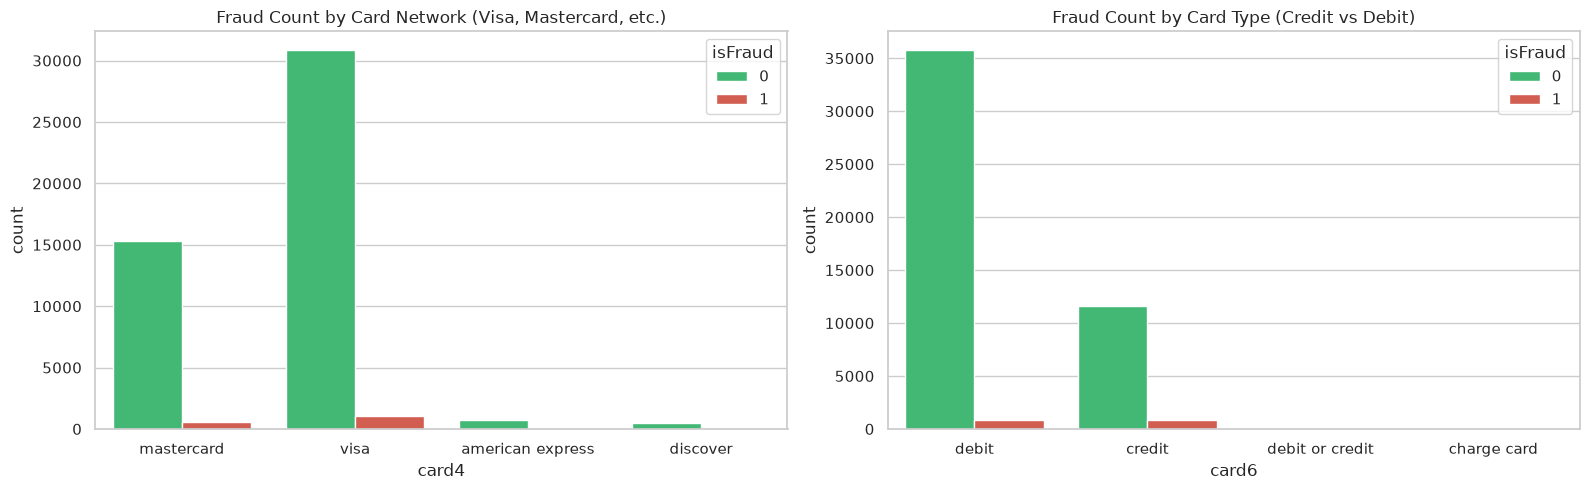

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Card Network vs Fraud
sns.countplot(
    data=train_df,
    x="card4",
    hue="isFraud",
    ax=axes[0],
    palette=["#2ecc71", "#e74c3c"],
)
axes[0].set_title("Fraud Count by Card Network (Visa, Mastercard, etc.)")

# Card Type vs Fraud
sns.countplot(
    data=train_df,
    x="card6",
    hue="isFraud",
    ax=axes[1],
    palette=["#2ecc71", "#e74c3c"],
)
axes[1].set_title("Fraud Count by Card Type (Credit vs Debit)")

plt.tight_layout()
plt.show()

> **Key Insight:**
> - **Card Network (`card4`):** Visa and Mastercard dominate overall transaction volume. While Visa has a higher total number of fraud cases, both major networks maintain relatively comparable fraud proportions.
> - **Card Type (`card6`):** Debit cards account for the majority of transaction volume; however, **Credit cards exhibit a significantly higher fraud-to-legitimate ratio** compared to Debit cards.

## 8. Purchaser Email Domain Analysis (`P_emaildomain`)

Analyze the primary email domain providers of purchasers to identify high-volume domains and evaluate variations in fraud risk across providers.

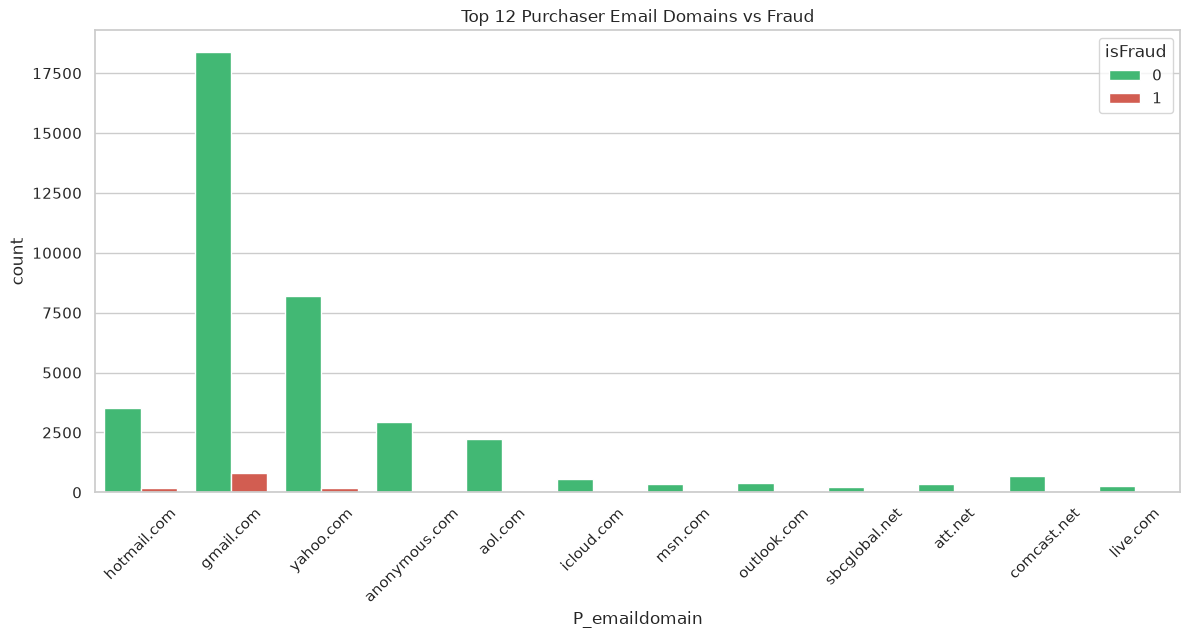

In [20]:
plt.figure(figsize=(14, 6))
top_emails = train_df["P_emaildomain"].value_counts().head(12).index
sns.countplot(
    data=train_df[train_df["P_emaildomain"].isin(top_emails)],
    x="P_emaildomain",
    hue="isFraud",
    palette=["#2ecc71", "#e74c3c"],
)
plt.title("Top 12 Purchaser Email Domains vs Fraud")
plt.xticks(rotation=45)
plt.show()

> **Key Insight:**
> - **Dominant Providers:** `gmail.com`, `yahoo.com`, and `hotmail.com` represent the majority of transaction volume.
> - **Risk Variance:** While `gmail.com` accounts for the largest absolute volume of fraudulent transactions, specific smaller domains (such as `hotmail.com` or `outlook.com`) show noticeable fraud proportions relative to their total volume.
> - **Feature Engineering Note:** Grouping obscure or low-frequency email domains into an "Other" category or mapping domain suffixes (e.g., corporate vs. public providers) can serve as useful features.

## 9. Device Info Analysis (`DeviceInfo`)

Analyze the primary device models and operating environments used during transactions to evaluate fraud concentrations across top hardware/software platforms.

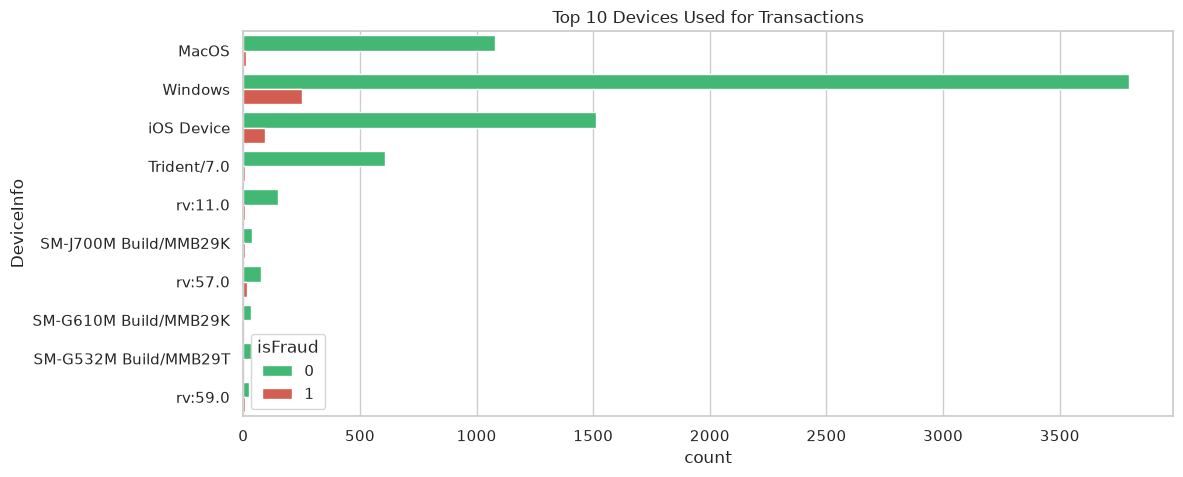

In [21]:
if "DeviceInfo" in train_df.columns:
    plt.figure(figsize=(12, 5))
    top_devices = train_df["DeviceInfo"].value_counts().head(10).index
    sns.countplot(
        data=train_df[train_df["DeviceInfo"].isin(top_devices)],
        y="DeviceInfo",
        hue="isFraud",
        palette=["#2ecc71", "#e74c3c"],
    )
    plt.title("Top 10 Devices Used for Transactions")
    plt.show()

> **Key Insight:**
> - **Dominant Platforms:** `Windows`, `iOS Device`, and `MacOS` dominate the overall volume among identified devices.
> - **Higher Fraud Concentration:** `Windows` and `iOS Device` account for the highest total volume of fraudulent transactions, with `Windows` showing a noticeably higher fraud proportion relative to other major platforms.
> - **Feature Engineering Note:** Device strings contain varied formats (e.g., specific build numbers vs. high-level OS names); extracting base operating system categories or grouping low-frequency build strings into broader groups can improve model generalization.

## 10. Correlation Analysis of C-Features (`C1`–`C14`)

Evaluate multicollinearity among the count-based features (`C1` through `C14`) to understand redundancy and identify highly correlated feature subsets.

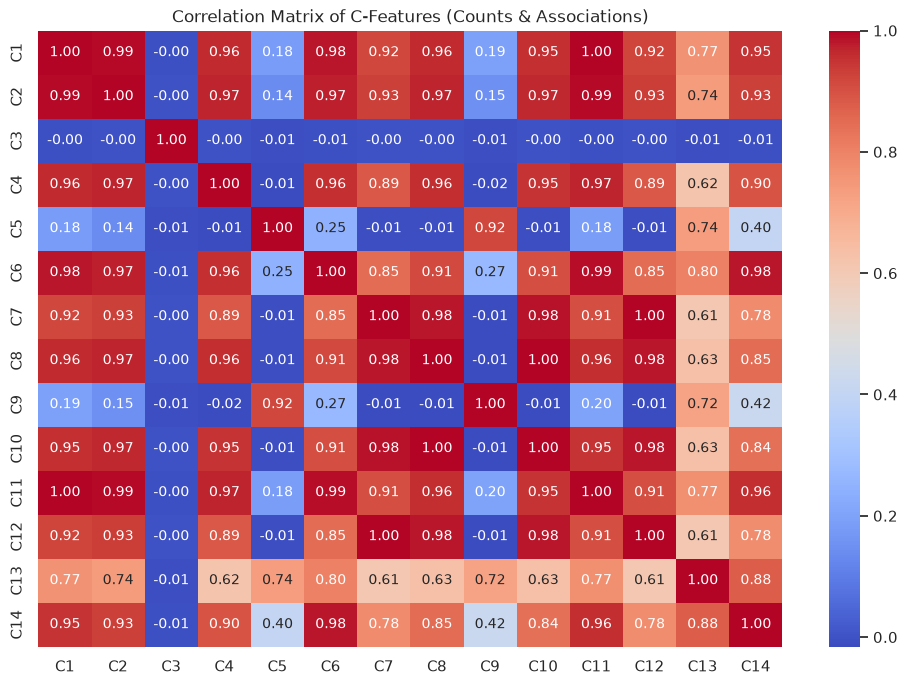

In [14]:
c_cols = [f"C{i}" for i in range(1, 15) if f"C{i}" in train_df.columns]

plt.figure(figsize=(12, 8))
sns.heatmap(train_df[c_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of C-Features (Counts & Associations)")
plt.show()

> **Key Insight:**
> - **Extreme Multicollinearity:** A significant portion of C-features exhibit near-perfect correlation with each other (e.g., `C1` & `C11` at **1.00**, `C7` & `C12` at **1.00**, and `C8` & `C10` at **1.00**).
> - **Distinct Features:** `C3` shows virtually no correlation (**~0.00**) with any other C-feature, while `C5` and `C9` form a separate correlated pair (**0.92**).
> - **Feature Engineering Strategy:** Highly correlated features carry redundant information. Aggregating them (e.g., mean, sum, or PCA) or eliminating duplicates during feature selection will prevent model overfitting and speed up training.

## 11. Analysis of Time Delta Feature (`D1`)

Evaluate the distribution of the `D1` feature (representing timedelta metrics such as days since a previous transaction/activity) to examine behavioral differences between legitimate and fraudulent accounts.

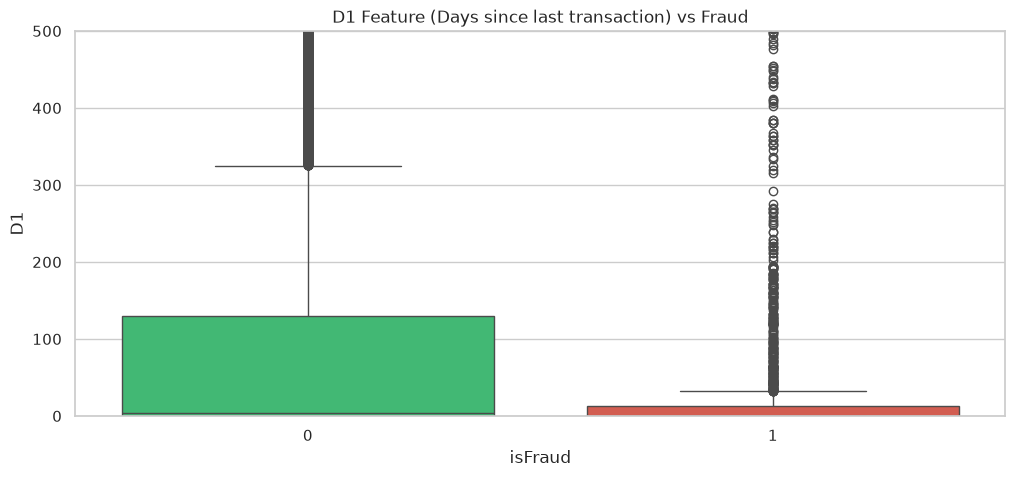

In [22]:
plt.figure(figsize=(12, 5))
sns.boxplot(
    data=train_df,
    x="isFraud",
    y="D1",
    hue="isFraud",
    palette=["#2ecc71", "#e74c3c"],
    legend=False,
)
plt.title("D1 Feature (Days since last transaction) vs Fraud")
plt.ylim(0, 500)
plt.show()

> **Key Insight:**
> - **Shorter Account/Activity Age:** Fraudulent transactions exhibit significantly lower `D1` values, with most fraud concentrated near 0 (newly created accounts or recent fresh activity).
> - **Legitimate Stability:** Legitimate transactions display a much wider IQR range extending up to 130+ days, reflecting longer account longevity and established behavior.
> - **Predictive Signal:** Time-delta attributes (`D1`–`D15`) serve as powerful features for separating new suspicious accounts from seasoned, low-risk users.

## 12. Dimensionality Reduction on V-Features (PCA)

Apply Principal Component Analysis (PCA) to condense the 339 V-features into 2 principal components to evaluate non-linear feature overlap and class separability in reduced space.

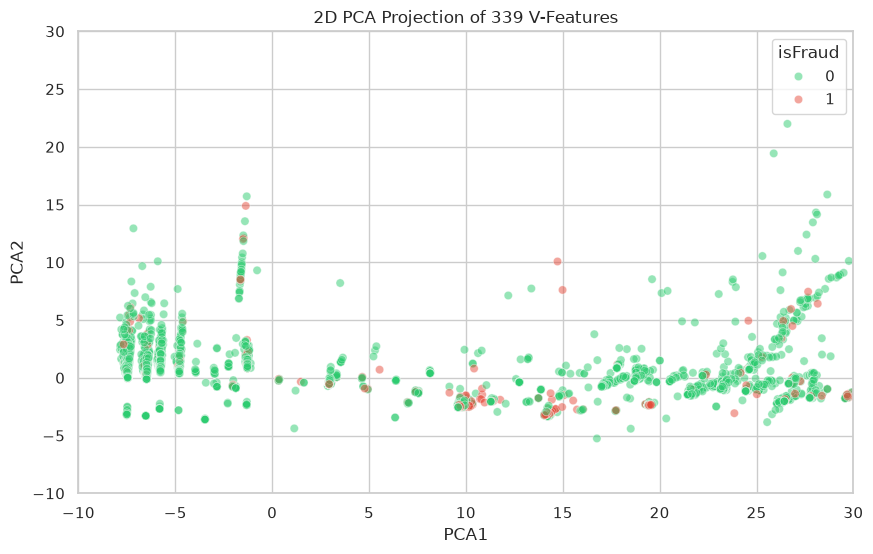

In [23]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

v_cols = [f"V{i}" for i in range(1, 340) if f"V{i}" in train_df.columns]

# Fill NaNs temporarily for PCA
v_data = train_df[v_cols].fillna(-999)

scaler = StandardScaler()
v_scaled = scaler.fit_transform(v_data)

pca = PCA(n_components=2)
v_pca = pca.fit_transform(v_scaled)

pca_df = pd.DataFrame(v_pca, columns=["PCA1", "PCA2"])
pca_df["isFraud"] = train_df["isFraud"].values

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=pca_df,
    x="PCA1",
    y="PCA2",
    hue="isFraud",
    alpha=0.5,
    palette=["#2ecc71", "#e74c3c"],
)
plt.title("2D PCA Projection of 339 V-Features")
plt.xlim(-10, 30)
plt.ylim(-10, 30)
plt.show()

> **Key Insight:**
> - **Class Overlap:** Fraudulent transactions are heavily overlapping with legitimate ones across the main clusters, demonstrating that 2 linear principal components cannot easily separate the classes in linear space.
> - **Clustering & Outliers:** The V-features form noticeable structural columns and clusters (e.g., around PCA1 between -8 to -5 and 10 to 20), indicating underlying grouping structures within the identity/transaction interactions.
> - **Modeling Strategy:** Since linear PCA projection leaves significant class overlap, non-linear tree algorithms like LightGBM are essential to capture complex, high-dimensional decision boundaries directly from raw or grouped V-features.

## 13. Summary & Modeling Next Steps

### Key EDA Findings
1. **Class Imbalance:** Extreme target imbalance (~3.5% fraud) requires metric optimization focused on **PR-AUC / ROC-AUC** and careful cross-validation strategy (Stratified K-Fold / TimeSeriesSplit).
2. **Temporal Dynamics:** Clear hourly seasonality in fraud rates peaking during early morning hours; extracting temporal features (`hour`, `dayofweek`) is essential.
3. **Card & Identity Patterns:** High risk concentration in specific card types (Credit) and identified device/browser platforms (`Windows`, `iOS Device`).
4. **Multicollinearity & High Dimensionality:** Severe redundancy in C-features and high density in V-features require feature aggregation, removal of highly correlated pairs, or letting tree ensembles handle interactions natively.
5. **Account Age Proxy (`D1`):** Time-delta metrics strongly differentiate new suspicious accounts from established legitimate users.

### Action Plan for Feature Engineering & Modeling
- **Preprocessing:** Apply missing value indicators for high-null features; handle unseen categories using frequency encoding and target encoding.
- **Feature Construction:** Create aggregation features (e.g., mean/std of `TransactionAmt` grouped by `card1`, `P_emaildomain`, etc.).
- **Validation Scheme:** Set up a time-based validation split to mimic production scenarios and prevent temporal data leakage.
- **Model Training:** Train a **LightGBM Baseline** using focal/weighted loss or tuned hyper-parameters to optimize fraud detection precision and recall.